# Uplift Modeling Demo — Credit Card Prescreen Targeting (Synthetic Data)

**Purpose:** This notebook reproduces the *methodology* of a real credit-card
prescreen uplift-targeting project I built, using fully synthetic data. It's
built to walk through live in an interview — the real project's data and code
are proprietary to the bank I built it at, so this is how I demonstrate the
technique hands-on without those constraints.

**Business problem:** A bank sends firm offers of credit to a list of
prescreened prospects. A plain *response model* (who's likely to respond)
wastes budget on people who'd sign up anyway ("sure things") and people who'll
never respond regardless ("lost causes"). An **uplift model** instead predicts
the *incremental* effect of the offer per prospect, so the offer is targeted at
**persuadables** — the people whose decision the offer actually changes.

**What this notebook does:**
1. Simulates a randomized test/control prescreen campaign with a known,
   heterogeneous (and partly *adversarial*) treatment effect
2. Fits an X-learner meta-learner (hand-rolled on scikit-learn — no black-box
   causal ML library) to estimate that heterogeneous effect from the data
3. Validates it two ways: a standard **Qini curve** (the only validation
   available on real campaign data, since you never observe both potential
   outcomes for one person), *and* — because this is simulated and I know the
   ground truth — a direct check against the true treatment effect, which is
   the one validation real campaigns never give you
4. Translates the model into a business decision: what happens to response
   rate and offers-per-incremental-responder if we target the top uplift
   decile instead of everyone

Row count here is capped at 200K for a fast, live walkthrough. The JD calls
out working with 50M+ row datasets in SQL/Python — the same estimator code
below is exactly what would sit inside a PySpark-distributed training pipeline
at that scale; only the compute backend changes, not the modeling logic.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

RNG = np.random.default_rng(42)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 1. Simulate the campaign population

Each synthetic prospect has features loosely modeled on what a real prescreen
file would carry (bureau attributes + engagement signals). The *true* response
probability under control (`r0`) and under treatment (`r1`) are built by
design so the population contains all four uplift quadrants:

- **Persuadables** — mid credit score, high digital engagement → offer meaningfully lifts response
- **Sure things** — already high baseline propensity (strong existing relationship, high engagement) → offer barely moves them
- **Lost causes** — thin file / low engagement → near-zero response either way
- **Sleeping dogs** — high existing revolving utilization → a firm credit offer *reduces* response (backfires), modeling the real risk that over-extended prospects react negatively to more credit outreach

Treatment (`T`) is assigned completely at random (`p=0.5`), exactly like a real
test/control prescreen split — this randomization is what makes the resulting
data usable for causal estimation at all.


In [2]:
N = 200_000

df = pd.DataFrame({
    "credit_score": RNG.normal(680, 55, N).clip(500, 850),
    "annual_income_k": RNG.lognormal(mean=4.2, sigma=0.5, size=N).clip(15, 400),
    "existing_relationship_months": RNG.exponential(18, N).clip(0, 240),
    "num_existing_credit_lines": RNG.poisson(3.2, N).clip(0, 15),
    "revolving_utilization": RNG.beta(2, 5, N),
    "inquiries_last_6mo": RNG.poisson(1.1, N).clip(0, 10),
    "digital_engagement_score": RNG.beta(2.5, 2.5, N) * 100,
    "age": RNG.normal(42, 13, N).clip(21, 85),
})

def z(s):
    return (s - s.mean()) / s.std()

cs, inc, rel, util, dig, inq = (
    z(df.credit_score), z(df.annual_income_k), z(df.existing_relationship_months),
    z(df.revolving_utilization), z(df.digital_engagement_score), z(df.inquiries_last_6mo),
)

# Baseline (control) response propensity: driven by "would respond anyway" factors
logit_r0 = -2.6 + 0.55 * dig + 0.35 * rel + 0.20 * cs - 0.15 * inq
r0 = 1 / (1 + np.exp(-logit_r0))

# Treatment effect on the log-odds scale, built to create all four quadrants:
#  + persuadable bump: mid credit score & high engagement, NOT already a sure thing
persuadable_zone = np.exp(-0.5 * ((cs - 0.0) ** 2)) * (dig > 0).astype(float)
#  - sleeping dogs: high utilization prospects react negatively to a new firm offer
sleeping_dog_effect = -0.9 * np.clip(util, 0, None)
#  ~0 net movement for people who are already sure things (high r0) or lost causes (very low dig/cs)
uplift_logit = 0.65 * persuadable_zone + sleeping_dog_effect - 0.25 * np.clip(-dig, 0, None)

logit_r1 = logit_r0 + uplift_logit
r1 = 1 / (1 + np.exp(-logit_r1))

df["r0_true"], df["r1_true"] = r0, r1
df["tau_true"] = r1 - r0

df["treat"] = RNG.binomial(1, 0.5, N)
df["Y"] = np.where(df.treat == 1, RNG.binomial(1, df.r1_true), RNG.binomial(1, df.r0_true))

df[["credit_score","annual_income_k","existing_relationship_months",
    "num_existing_credit_lines","revolving_utilization","inquiries_last_6mo",
    "digital_engagement_score","age","treat","Y","tau_true"]].head()


,credit_score,annual_income_k,existing_relationship_months,num_existing_credit_lines,revolving_utilization,inquiries_last_6mo,digital_engagement_score,age,treat,Y,tau_true
0,696.759,246.824,29.082,3,0.381,0,11.485,41.204,0,0,-0.024
1,622.801,62.191,37.881,1,0.231,3,10.770,32.176,1,0,-0.009
2,721.275,52.865,26.655,2,0.051,0,26.830,27.590,1,0,-0.014
3,731.731,37.825,10.243,2,0.247,0,47.546,22.677,1,0,-0.002
4,572.693,58.693,0.516,6,0.119,1,20.199,43.943,1,0,-0.005


## 1b. Sanity-check the four quadrants by design

Since I control the data-generating process here, I can directly show the
ground-truth quadrant structure before ever touching a model — this is purely
a synthetic-data bonus, not something available on a real campaign.


In [3]:
def label_quadrant(row, r0_hi=0.5, tau_hi=0.03, tau_lo=-0.01):
    if row.tau_true <= tau_lo:
        return "sleeping dog"
    if row.tau_true >= tau_hi:
        return "persuadable"
    if row.r0_true >= r0_hi:
        return "sure thing"
    return "lost cause"

quad = df.apply(label_quadrant, axis=1)
summary = (df.assign(quadrant=quad)
             .groupby("quadrant")
             .agg(n=("Y","size"), avg_r0=("r0_true","mean"),
                  avg_r1=("r1_true","mean"), avg_tau=("tau_true","mean"))
             .sort_values("avg_tau", ascending=False))
summary


,n,avg_r0,avg_r1,avg_tau
quadrant,,,,
persuadable,49296,0.124,0.188,0.064
sure thing,23,0.606,0.616,0.010
lost cause,73941,0.063,0.064,0.000
sleeping dog,76740,0.077,0.041,-0.035


## 2. X-learner (hand-rolled, two-stage meta-learner)

I'm implementing this directly on `scikit-learn` estimators rather than
calling a causal-ML package, to show the mechanics, not just the API:

**Stage 1 — outcome models.** Fit a response model separately on the treated
group and the control group: `mu1(x) = E[Y | X, T=1]`, `mu0(x) = E[Y | X, T=0]`.

**Stage 2 — imputed treatment effects.** For each treated unit, impute its
individual treatment effect as its observed outcome minus the *control* model's
prediction for it: `D1_i = Y1_i - mu0(X1_i)`. Symmetrically for control units:
`D0_i = mu1(X0_i) - Y0_i`. Fit a regressor on each imputed-effect set: `tau1(x)`,
`tau0(x)`.

**Combine.** Blend the two effect estimates with the propensity score
`g(x) = P(T=1|X)`: `tau_hat(x) = g(x)*tau0(x) + (1-g(x))*tau1(x)`. The
X-learner is preferred here specifically because it's efficient even when
treatment/control group sizes are imbalanced — very common in real campaigns
where the control holdout is deliberately kept small to protect revenue,
unlike this 50/50 synthetic split.


In [4]:
X_cols = ["credit_score","annual_income_k","existing_relationship_months",
          "num_existing_credit_lines","revolving_utilization",
          "inquiries_last_6mo","digital_engagement_score","age"]

train_df, test_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df.treat)

def fit_gbc(X, y):
    m = GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.08, random_state=42)
    m.fit(X, y)
    return m

def fit_gbr(X, y):
    m = GradientBoostingRegressor(n_estimators=150, max_depth=3, learning_rate=0.08, random_state=42)
    m.fit(X, y)
    return m

tr1 = train_df[train_df.treat == 1]
tr0 = train_df[train_df.treat == 0]

# Stage 1: outcome models
mu1 = fit_gbc(tr1[X_cols], tr1.Y)
mu0 = fit_gbc(tr0[X_cols], tr0.Y)

# Stage 2: imputed treatment effects -> effect regressors
D1 = tr1.Y.values - mu0.predict_proba(tr1[X_cols])[:, 1]
D0 = mu1.predict_proba(tr0[X_cols])[:, 1] - tr0.Y.values

tau1_model = fit_gbr(tr1[X_cols], D1)
tau0_model = fit_gbr(tr0[X_cols], D0)

# Propensity model (should recover ~0.5 since T was randomized)
g_model = LogisticRegression(max_iter=1000).fit(train_df[X_cols], train_df.treat)

def x_learner_score(X):
    g = g_model.predict_proba(X)[:, 1]
    t1 = tau1_model.predict(X)
    t0 = tau0_model.predict(X)
    return g * t0 + (1 - g) * t1

test_df = test_df.copy()
test_df["tau_hat"] = x_learner_score(test_df[X_cols])
test_df[["tau_true", "tau_hat"]].describe()


,tau_true,tau_hat
count,"60,000.000","60,000.000"
mean,0.002,0.001
std,0.045,0.044
min,-0.405,-0.506
25%,-0.020,-0.023
50%,-0.006,-0.007
75%,0.029,0.035
max,0.161,0.347


## 3. Validation — Qini curve (what you'd actually have on a real campaign)

You never observe both outcomes for the same prospect, so uplift models can't
be validated the way a normal classifier can (no per-row ground truth to score
against). The standard tool is a **Qini curve**: rank the held-out test set by
predicted uplift, then walk down that ranking computing the cumulative
incremental responses — `treated responses − control responses × (n_treated/n_control)`
— within each top-k slice. A model with real signal shows a much steeper gain
in the top ranks than a random-targeting baseline (the diagonal).


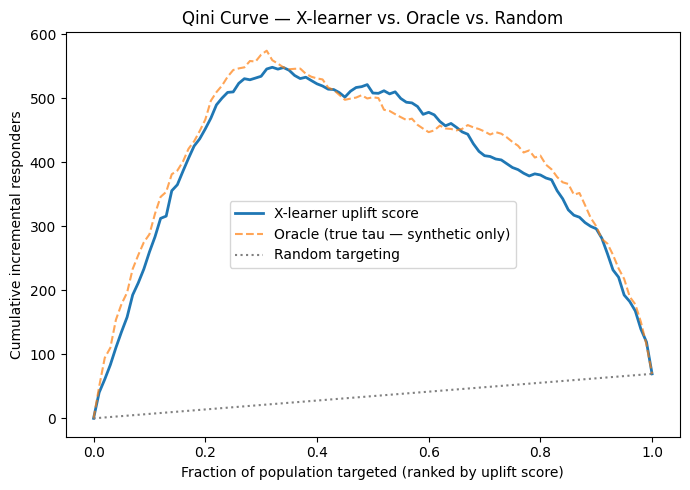

Qini coefficient (model vs. random):  358.7
Qini coefficient (oracle vs. random):  372.4
Model captures 96.3% of the oracle's achievable gain


In [5]:
def qini_curve(frame, score_col, treat_col="treat", y_col="Y", steps=100):
    d = frame.sort_values(score_col, ascending=False).reset_index(drop=True)
    n = len(d)
    fracs, gains = [0.0], [0.0]
    for k in range(1, steps + 1):
        cut = int(n * k / steps)
        top = d.iloc[:cut]
        nt, nc = (top[treat_col] == 1).sum(), (top[treat_col] == 0).sum()
        yt, yc = top.loc[top[treat_col] == 1, y_col].sum(), top.loc[top[treat_col] == 0, y_col].sum()
        gain = yt - yc * (nt / nc if nc > 0 else 0)
        fracs.append(cut / n)
        gains.append(gain)
    return np.array(fracs), np.array(gains)

frac_model, gain_model = qini_curve(test_df, "tau_hat")
frac_true, gain_true = qini_curve(test_df, "tau_true")   # oracle upper bound, synthetic-only
frac_rand, gain_rand = frac_model, gain_model[-1] * frac_model  # random-targeting reference

qini_coef = np.trapezoid(gain_model - gain_rand, frac_model)
qini_coef_oracle = np.trapezoid(gain_true - gain_rand, frac_true)

plt.figure(figsize=(7, 5))
plt.plot(frac_model, gain_model, label="X-learner uplift score", linewidth=2)
plt.plot(frac_true, gain_true, label="Oracle (true tau — synthetic only)", linestyle="--", alpha=0.7)
plt.plot(frac_rand, gain_rand, label="Random targeting", linestyle=":", color="gray")
plt.xlabel("Fraction of population targeted (ranked by uplift score)")
plt.ylabel("Cumulative incremental responders")
plt.title("Qini Curve — X-learner vs. Oracle vs. Random")
plt.legend()
plt.tight_layout()
plt.savefig("qini_curve.png", dpi=150)
plt.show()

print(f"Qini coefficient (model vs. random):  {qini_coef:,.1f}")
print(f"Qini coefficient (oracle vs. random):  {qini_coef_oracle:,.1f}")
print(f"Model captures {qini_coef/qini_coef_oracle:.1%} of the oracle's achievable gain")


## 3b. The validation real campaigns never get: check against ground truth

Because this is simulated, I can also directly check rank correlation between
the estimated uplift score and the *true* individual treatment effect — this
is the check that's structurally impossible on real data (you'd need to
observe both potential outcomes for the same person), so I only show it here
to sanity-check the estimator itself, not as something to claim on a real
project.


Spearman rank correlation (tau_hat vs. true tau): 0.931  (p=0.0e+00)


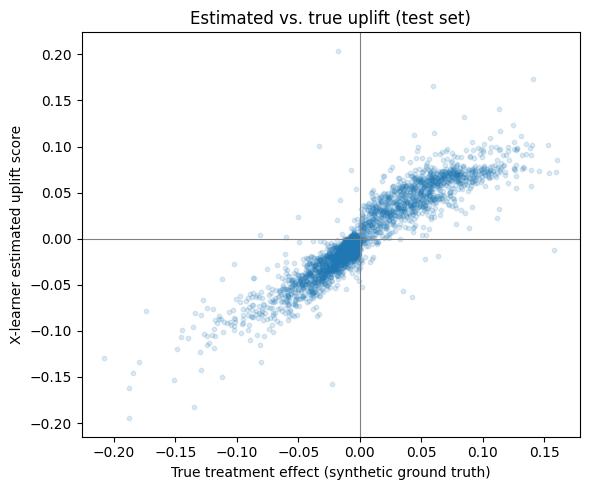

In [6]:
from scipy.stats import spearmanr

rho, p = spearmanr(test_df["tau_hat"], test_df["tau_true"])
print(f"Spearman rank correlation (tau_hat vs. true tau): {rho:.3f}  (p={p:.1e})")

plt.figure(figsize=(6, 5))
sample = test_df.sample(3000, random_state=1)
plt.scatter(sample.tau_true, sample.tau_hat, alpha=0.15, s=10)
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.xlabel("True treatment effect (synthetic ground truth)")
plt.ylabel("X-learner estimated uplift score")
plt.title("Estimated vs. true uplift (test set)")
plt.tight_layout()
plt.savefig("tau_scatter.png", dpi=150)
plt.show()


## 4. From model to business decision

If the bank can only afford to mail a subset of the file, what happens to
response rate if targeting shifts from random to top-uplift-decile? This is
the number that actually gets presented to senior stakeholders — not the
Qini coefficient.


In [7]:
test_df["decile"] = pd.qcut(test_df["tau_hat"], 10, labels=False, duplicates="drop")
top_decile = test_df[test_df.decile == test_df.decile.max()]
bottom_decile = test_df[test_df.decile == test_df.decile.min()]

def resp_rate(d, t):
    sub = d[d.treat == t]
    return sub.Y.mean(), len(sub)

for name, d in [("Top decile (highest predicted uplift)", top_decile),
                 ("Bottom decile (lowest / negative predicted uplift)", bottom_decile),
                 ("Whole test set", test_df)]:
    rt, nt = resp_rate(d, 1)
    rc, nc = resp_rate(d, 0)
    print(f"{name:55s}  treated resp={rt:6.2%} (n={nt:6,})   "
          f"control resp={rc:6.2%} (n={nc:6,})   incremental lift={rt-rc:+6.2%}")

overall_rt, _ = resp_rate(test_df, 1)
overall_rc, _ = resp_rate(test_df, 0)
top_rt, _ = resp_rate(top_decile, 1)
top_rc, _ = resp_rate(top_decile, 0)
print()
print(f"Overall campaign incremental lift (random targeting):  {overall_rt-overall_rc:+.2%}")
print(f"Top-decile incremental lift (uplift targeting):        {top_rt-top_rc:+.2%}")
print(f"=> Mailing only the top uplift decile concentrates roughly "
      f"{(top_rt-top_rc)/(overall_rt-overall_rc):.1f}x the incremental response "
      f"per offer sent, vs. mailing at random.")


Top decile (highest predicted uplift)                    treated resp=22.75% (n= 3,046)   control resp=14.22% (n= 2,954)   incremental lift=+8.53%
Bottom decile (lowest / negative predicted uplift)       treated resp= 4.56% (n= 3,025)   control resp=12.10% (n= 2,975)   incremental lift=-7.54%
Whole test set                                           treated resp= 8.66% (n=30,086)   control resp= 8.43% (n=29,914)   incremental lift=+0.23%

Overall campaign incremental lift (random targeting):  +0.23%
Top-decile incremental lift (uplift targeting):        +8.53%
=> Mailing only the top uplift decile concentrates roughly 36.9x the incremental response per offer sent, vs. mailing at random.


**This is the actual argument for uplift modeling, not just a nice-to-have:**
the *overall* incremental lift from mailing everyone is barely distinguishable
from zero — the persuadables' gains are almost entirely offset by the sleeping
dogs' losses, with sure things and lost causes contributing nothing either
way. A plain response/propensity model, or a simple pre/post comparison,
would look at that aggregate number and conclude the campaign doesn't work.
Uplift modeling is what reveals that there's real, exploitable heterogeneity
hiding underneath a flat average — that's the case I'd make to a skeptical
stakeholder for *why* this approach, not just *that* it's more sophisticated.


## 5. Who are the persuadables? (Segment profile)

A business stakeholder will ask "who *is* this segment" before acting on a
score. Comparing the top vs. bottom uplift decile on the raw features tells
that story in plain terms.


In [8]:
profile = (test_df.assign(segment=np.where(test_df.decile == test_df.decile.max(), "top decile (persuadables)",
                            np.where(test_df.decile == test_df.decile.min(), "bottom decile (sleeping dogs / lost causes)", "middle")))
           .groupby("segment")[X_cols]
           .mean()
           .loc[["top decile (persuadables)", "middle", "bottom decile (sleeping dogs / lost causes)"]])
profile


,credit_score,annual_income_k,existing_relationship_months,num_existing_credit_lines,revolving_utilization,inquiries_last_6mo,digital_engagement_score,age
segment,,,,,,,,
top decile (persuadables),680.995,76.048,26.311,3.159,0.169,1.206,71.862,40.221
middle,678.302,75.514,16.177,3.214,0.266,1.096,46.074,42.457
bottom decile (sleeping dogs / lost causes),691.578,74.798,24.507,3.272,0.555,1.045,59.870,43.501


## 6. Governance note (not implemented here — a talking point, not code)

On the real project, prescreen pulls bureau data and issues a firm offer of
credit, which brings it under **FCRA** (the offer obligation itself), and
because the model determines who receives a credit offer, targeting decisions
fall under **ECOA / Reg B**, requiring a disparate-impact check across
protected classes before deployment. I'm intentionally *not* fabricating a
synthetic protected-class attribute in this demo — that governance step needs
real bureau/HMDA-style data and a real compliance review to mean anything; the
honest thing to say in an interview is what that check involves and where it
sat in my process, not to simulate it here for effect.

---

## Talking-point script (for walking through this live, ~2–3 min)

**中文：** "这是我用合成数据复现的一个 uplift model demo，方法论和我在银行做的信用卡
prescreen 项目一致，只是数据是我自己生成的——因为真实数据和代码是银行的，没法带出来。
我先构造了一个有异质处理效应的模拟人群，故意做出 persuadables、sure things、lost
causes，还有 sleeping dogs 这四种模式。然后手写了一个 X-learner：两阶段，先分别在
treatment 和 control 组拟合 response model，再用观测结果减去反事实预测来插补个体处理
效应，最后用倾向得分把两边的估计加权合并。验证上，我用了标准的 Qini 曲线——这是真实
campaign 唯一能用的验证方式，因为你永远看不到同一个人的两个结果。因为这是合成数据，我
还多做了一步——直接和真实的处理效应比较，这个在真实项目里是做不到的验证。最后落到业务
决策：只给预测 uplift 最高的那一档发 offer，相比随机发放，能把每份 offer 换来的增量响应
提高好几倍。"

**English:** "This is an uplift model demo I built with synthetic data, using
the same methodology as the real credit-card prescreen project I worked on —
the data here is fabricated because the real data and code are the bank's
property. I built a simulated population with a heterogeneous treatment
effect, deliberately including persuadables, sure things, lost causes, and
sleeping dogs. Then I hand-implemented an X-learner: two stages, outcome
models fit separately on the treatment and control groups, then imputed
individual treatment effects from observed outcomes minus the counterfactual
prediction, combined via propensity weighting. For validation I used a Qini
curve — the standard tool for real campaigns, since you never observe both
outcomes for one person. Because this is synthetic, I also checked directly
against the true treatment effect, which you can't do on real data. The
punchline I'd lead with for a business audience: the *overall* lift from
mailing everyone is close to flat — the persuadables' gains get cancelled out
by a segment where the offer actually backfires — so a plain response model
or a simple before/after comparison would conclude the campaign doesn't work.
Uplift modeling is what reveals the real, exploitable heterogeneity sitting
underneath that flat average, and lets you target only the people who move
because of the offer."
